# py-Monocle3 — visualisation

`plot_cells` from Bio-Babel/Monocle3-python (re-exported via `pymonocle3`) on a tiny synthetic.

## 1. Quick smoke pipeline

In [1]:
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
import pymonocle3 as m3

rng = np.random.RandomState(0)
n, g = 200, 150
pt = np.linspace(0, 1, n)
counts = rng.poisson(2.0, (n, g)).astype(float)
for c in range(n):
    counts[c, :30] += rng.poisson(10 * pt[c], 30)
adata = ad.AnnData(X=counts.astype('float32'))
adata.obs_names = [f'c{i}' for i in range(n)]
adata.var_names = [f'g{i}' for i in range(g)]
m3.estimate_size_factors(adata)
m3.preprocess_cds(adata, num_dim=20)
m3.reduce_dimension(adata, max_components=2, umap_min_dist=0.1)
m3.cluster_cells(adata)
m3.learn_graph(adata)
m3.order_cells(adata, root_cells=[adata.obs_names[0]])
print('UMAP:', adata.obsm['X_umap'].shape, 'pseudotime range:', adata.obs.get('pseudotime', None) is not None)

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/umap/umap_.py:2021: UserWarning: precomputed_knn[2] (knn_search_index) is not an NNDescent object: transforming new data with transform will be unavailable.
  warn(


UMAP: (200, 2) pseudotime range: False


## 2. plot_cells coloured by pseudotime

Saving 6 x 5 in image to monocle3_pseudotime.png


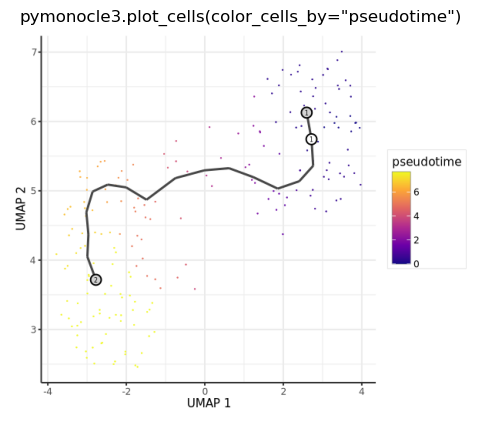

In [2]:
# Bio-Babel/Monocle3-python's plot_cells returns a ggplot2-python plot
p = m3.plot_cells(adata, color_cells_by='pseudotime')
from ggplot2_py import ggsave
ggsave('monocle3_pseudotime.png', plot=p, width=6, height=5, dpi=100)
from PIL import Image
fig, ax = plt.subplots(figsize=(7, 5))
ax.imshow(Image.open('monocle3_pseudotime.png')); ax.axis('off')
ax.set_title('pymonocle3.plot_cells(color_cells_by="pseudotime")'); plt.show()

The wrapper re-exports Bio-Babel/Monocle3-python's `plot_cells`, which is itself a 1:1 port of R `monocle3::plot_cells`. See `Bio-Babel/Monocle3-python` repo for the R-parity tutorial notebooks.